## Modelado con Gaussian Mixture Model (GMM)


In [437]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings
from math import pi
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


warnings.filterwarnings('ignore')


### Preparacion de datos

In [438]:
df_dqi =pd.read_csv('./Data/Processed/df_dqi_final.csv', sep=';')
df_clustering_pca = pd.read_csv('./Data/Processed/df_clustering_pca.csv', sep=';')
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,False,True,False,False,False,False,False,True,False,False
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,False,True,False,False,False,False,False,True,False,False


### Funciones para evaluar GMM

In [439]:
def gmm(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        gmm = GaussianMixture(n_components=cluster, random_state=42, max_iter=10000)
        gmm.fit(X)
        labels = gmm.predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


def plot_component_spider_plotly(means, n_components):
    num_features = means.shape[1]
    feature_labels = [f'C {i + 1}' for i in range(num_features)]
    data = []
    for i in range(n_components):
        values = means[i].tolist() + [means[i][0]] 
        data.append(values)

    df = pd.DataFrame(data, columns=feature_labels + ['Caracteristica 1'])
    df['componente'] = [f'componente {i + 1}' for i in range(n_components)]
    df = pd.melt(df, id_vars='componente', value_vars=feature_labels, 
                 var_name='Caracteristica', value_name='Valor')
    fig = px.line_polar(df, r='Valor', theta='Caracteristica', color='componente', 
                        line_close=True, title=f'Spider Plot para {n_components} componentes')
    fig.update_traces(fill='toself', opacity=0.25)
    fig.show()


### Ejecutamos la evaluacion de GMM con los datos listos

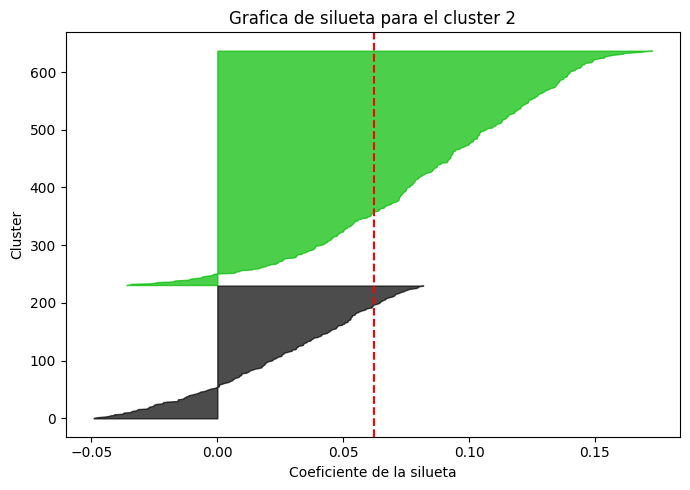

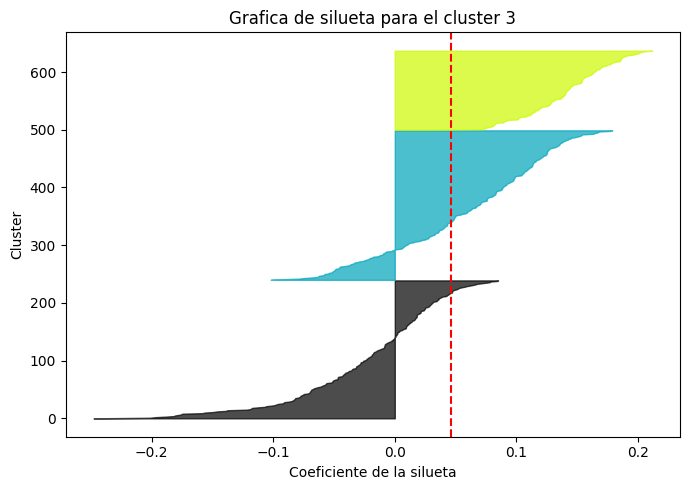

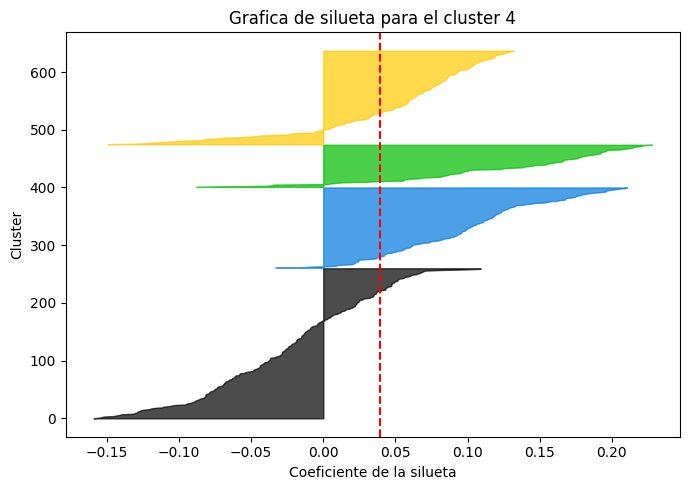

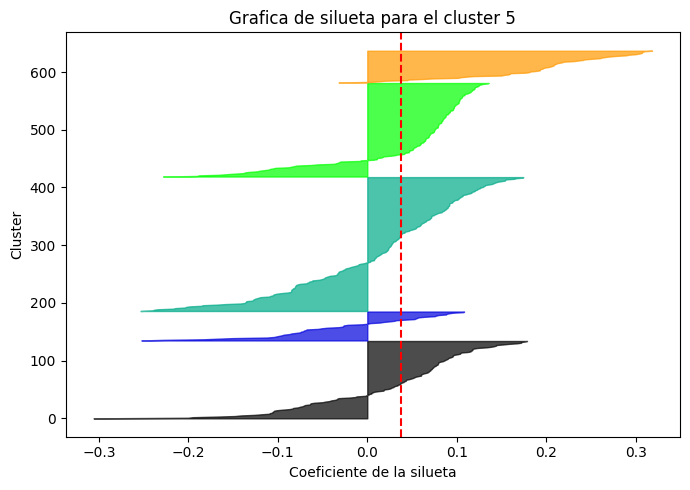

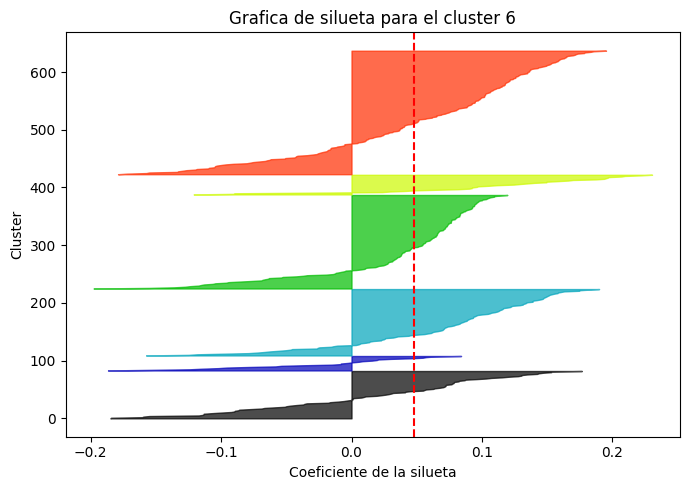

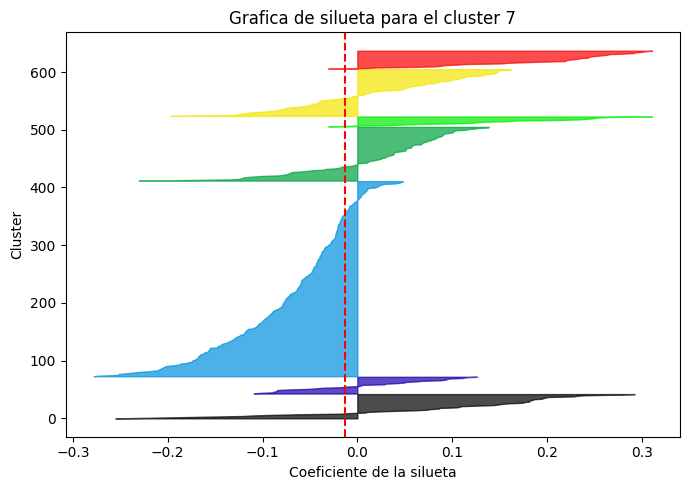

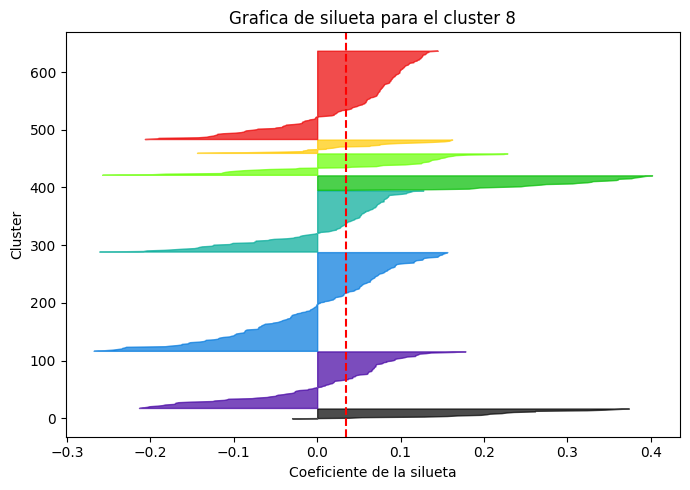

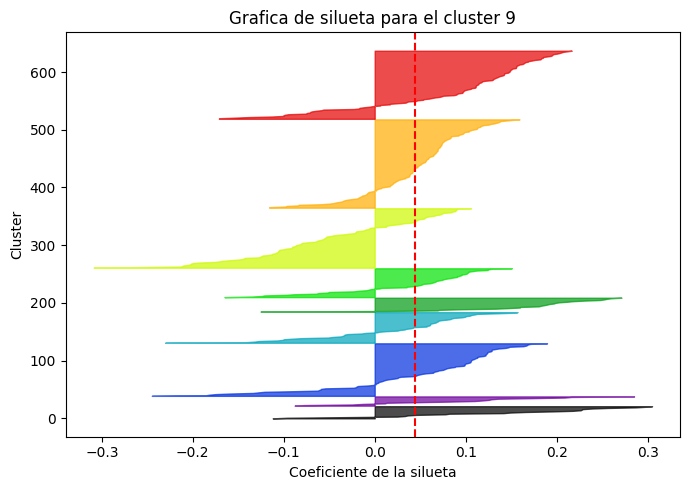

cluster = 2, Puntaje de Silueta = 0.062390739853527326
cluster = 3, Puntaje de Silueta = 0.04600697498302139
cluster = 4, Puntaje de Silueta = 0.03915600838511197
cluster = 5, Puntaje de Silueta = 0.03742678209141021
cluster = 6, Puntaje de Silueta = 0.047809958045305176
cluster = 7, Puntaje de Silueta = -0.012687564882130192
cluster = 8, Puntaje de Silueta = 0.03481800816420908
cluster = 9, Puntaje de Silueta = 0.04429659811293166


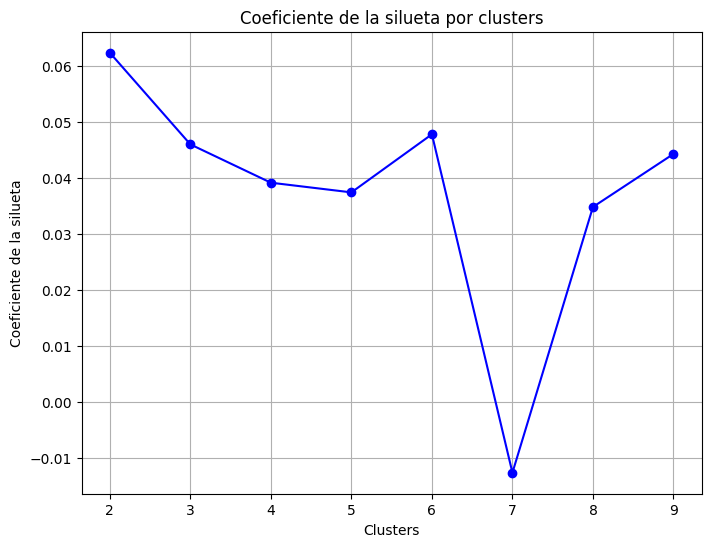

In [440]:
clusters = range(2, 10)  
puntaje_de_silueta = gmm(df_clustering_pca, clusters)
for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


In [441]:
components = 2
gmm = GaussianMixture(n_components=components, random_state=42, max_iter=10000)
gmm.fit(df_clustering_pca)
labels = gmm.predict(df_clustering_pca)
plot_component_spider_plotly(gmm.means_,components)
score = silhouette_score(df_clustering_pca, labels)

print(score)


0.062390739853527326


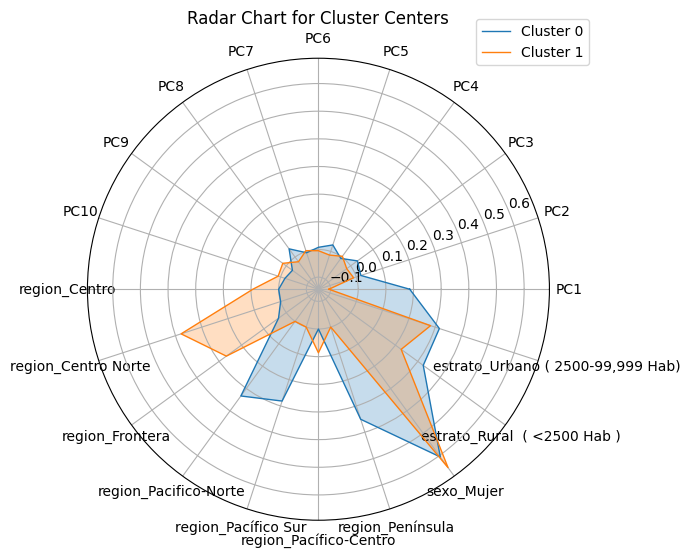

In [442]:
def plot_radar_chart(df, labels):
    cluster_data = pd.concat([df, pd.Series(labels, name='Cluster')], axis=1)
    cluster_centers = cluster_data.groupby('Cluster').mean()
    
    if -1 in cluster_centers.index:  # Remover puntos de ruido si están presentes
        cluster_centers = cluster_centers.drop(index=-1)

    categories = cluster_centers.columns
    num_vars = len(categories)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for idx, row in cluster_centers.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'Cluster {idx}')
        ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_title('Radar Chart for Cluster Centers')
    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    plt.show()



df_dqi_numeric = df_clustering_pca.select_dtypes(include=['number'])
plot_radar_chart(df_dqi_numeric, labels)

In [443]:
df_dqi = df_dqi.assign(Cluster=labels)
df_dqi.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",Cluster
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,True,False,False,False,False,False,True,False,False,1
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,1
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,True,False,False,False,False,False,True,False,False,1
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,1
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,True,False,False,False,False,False,True,False,False,1


In [444]:


df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())
df_dqi.head()



,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adecuacy,dqi_total,edad,ponderador,grupo,resultado_general_entrevista,Cluster,region,estrato,sexo
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,31,60,51,0.000122,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
1,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,32,58,26,0.000723,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
2,2022_01001042_01,0,0,0,3,0,0,0,6,9,...,31,60,62,0.000099,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
3,2022_01001075_02,0,0,0,0,0,0,0,6,6,...,20,40,33,0.000385,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2022_01001081_02,0,0,0,0,0,0,0,6,6,...,37,63,60,0.000222,Adolescentes y Adultos,1,1,Centro Norte,Rural ( <2500 Hab ),Mujer


### Distribucion del DQI por cluster 

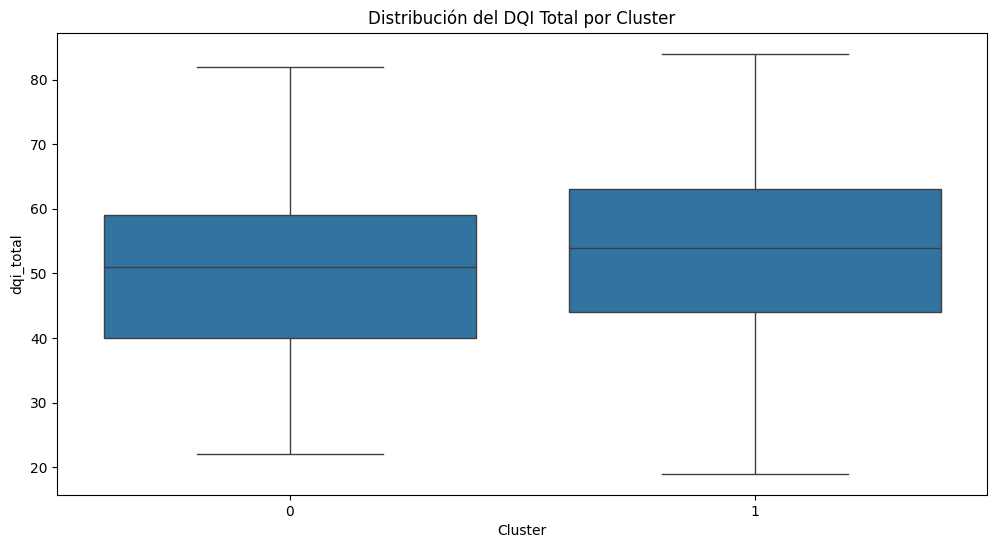

In [445]:
# generar boxplot para dos columnas
def boxplot(df, x, y, hue=None, title=None):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=x, y=y, hue=hue, data=df)
    plt.title(title)
    plt.show()

boxplot(df_dqi, 'Cluster', 'dqi_total', title='Distribución del DQI Total por Cluster')

La grafica de arriba muestra que no hay una diferencia muy grande entre la distribucion del DQI entre los dos clusters. El cluster 1 tiene valores mayores pero existe una sobre posicion muy grande entre los dos clusters.

### Distribucion de las variables por cluster 

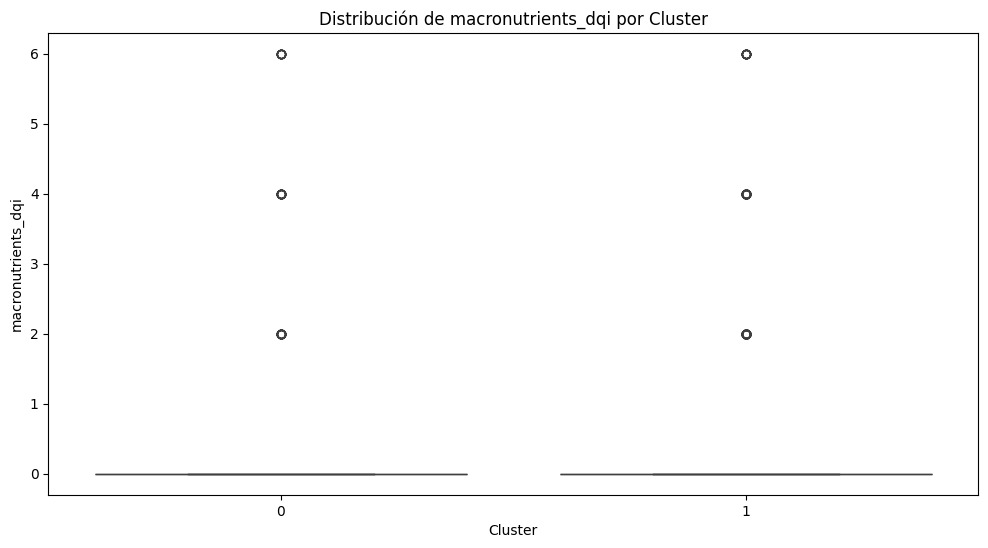

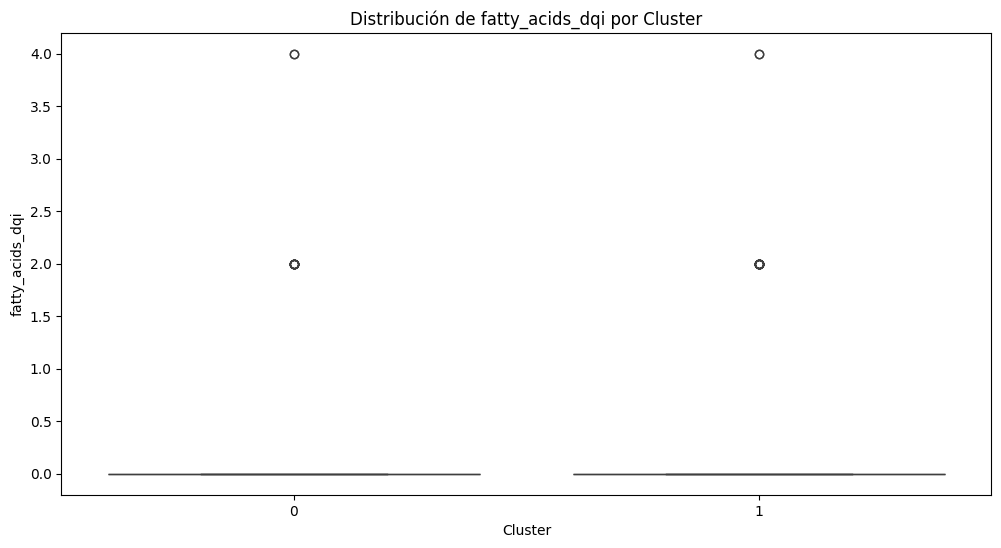

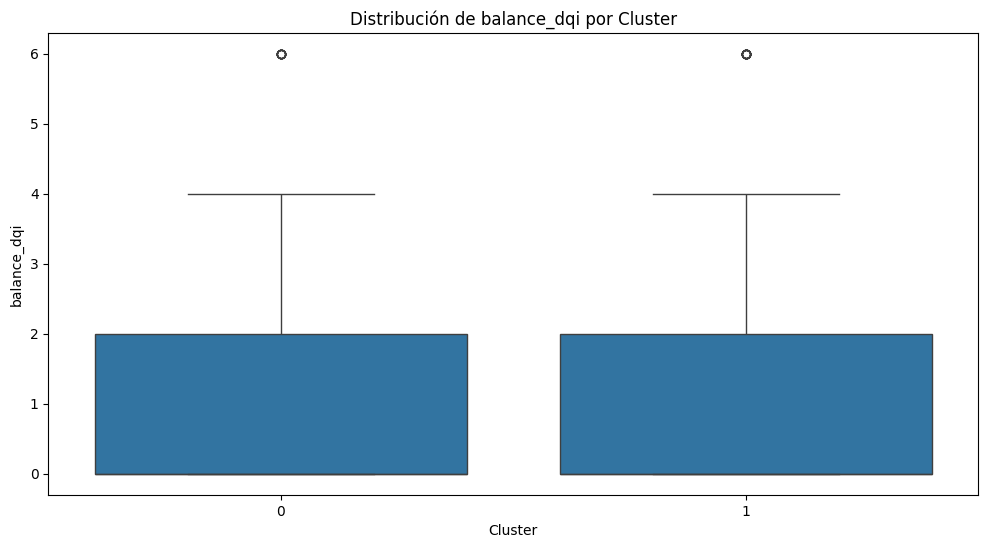

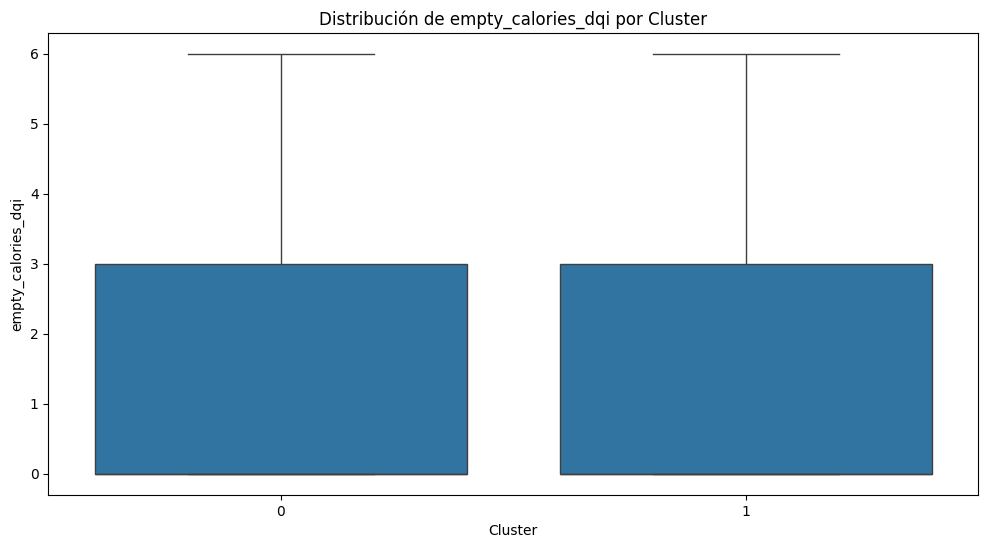

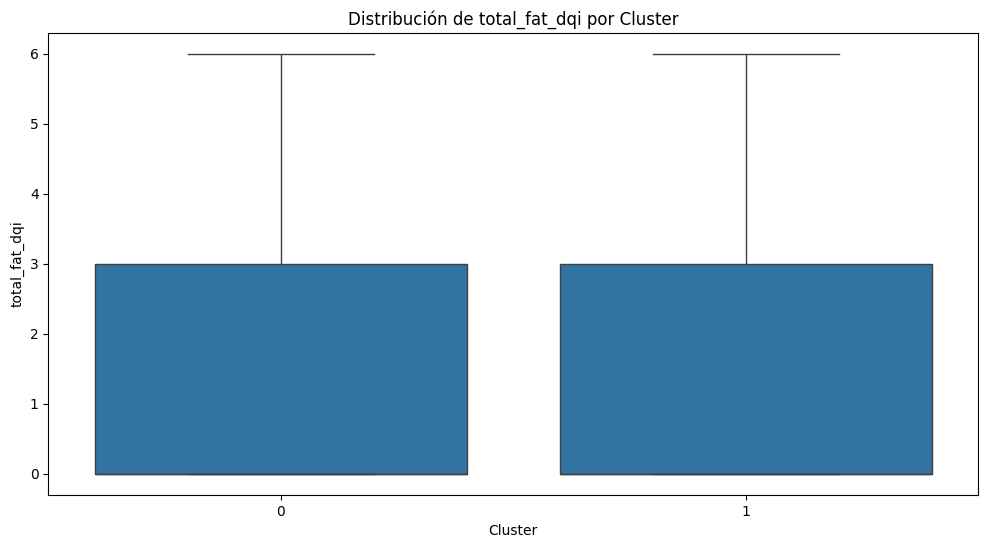

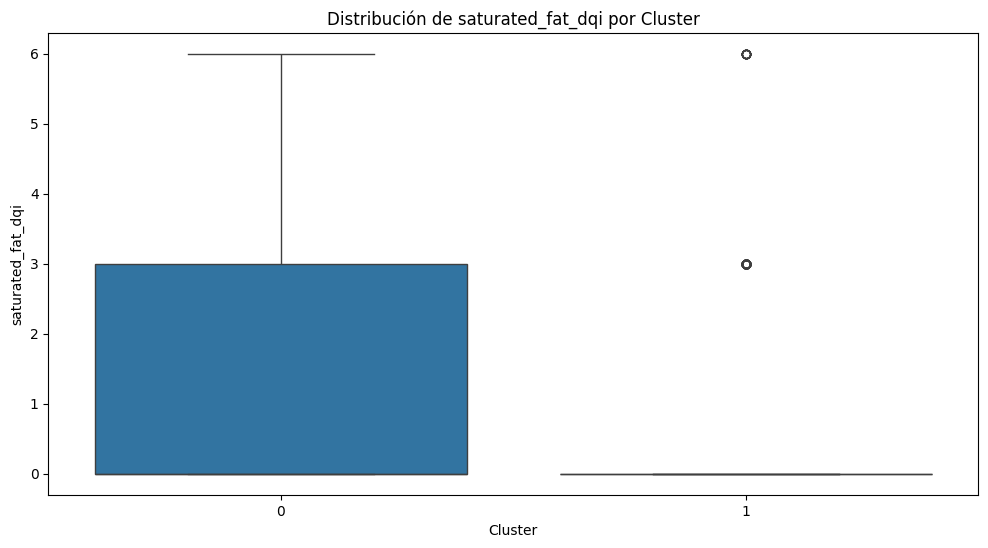

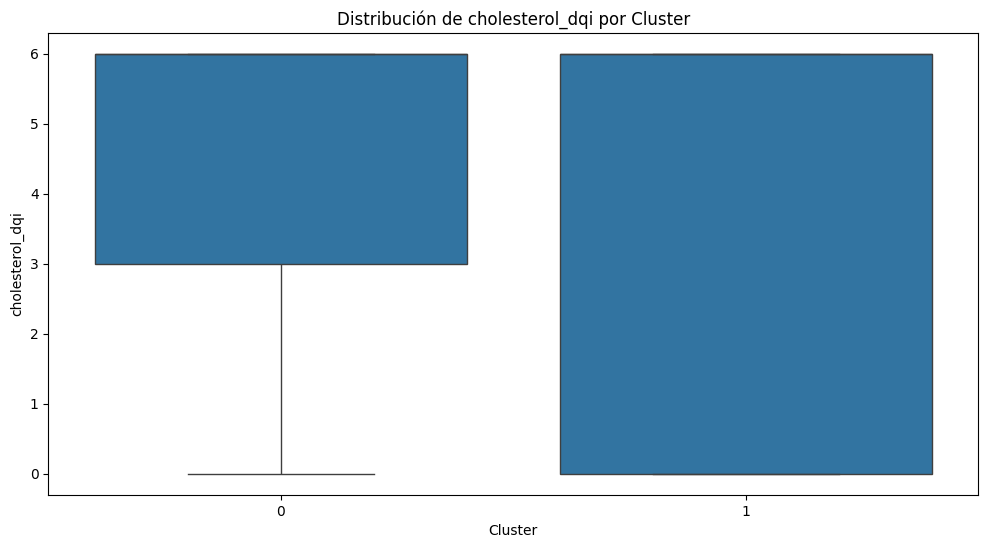

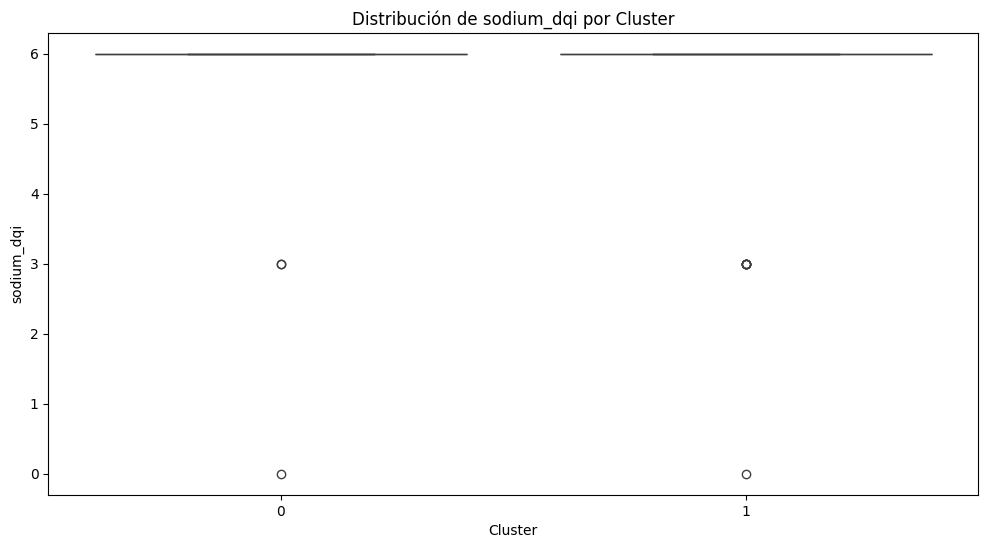

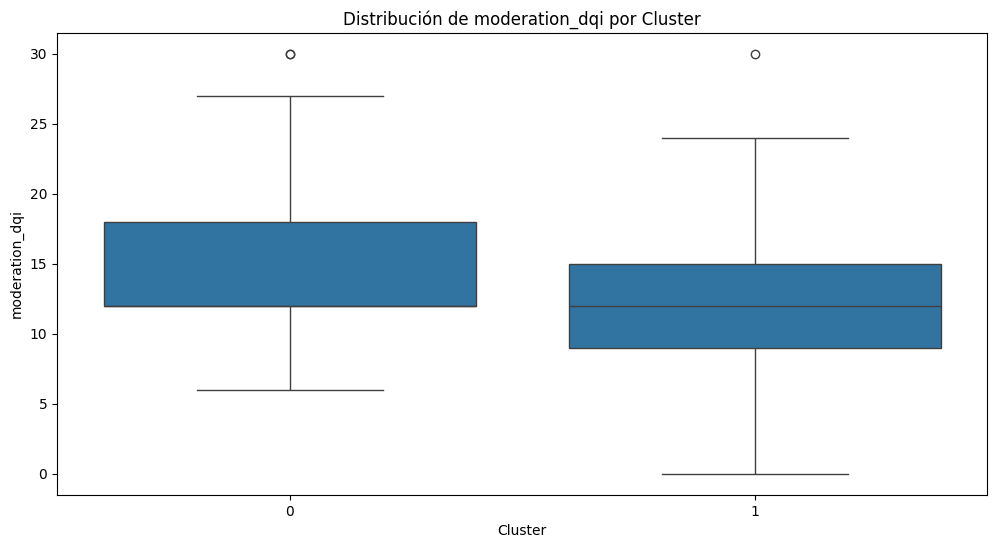

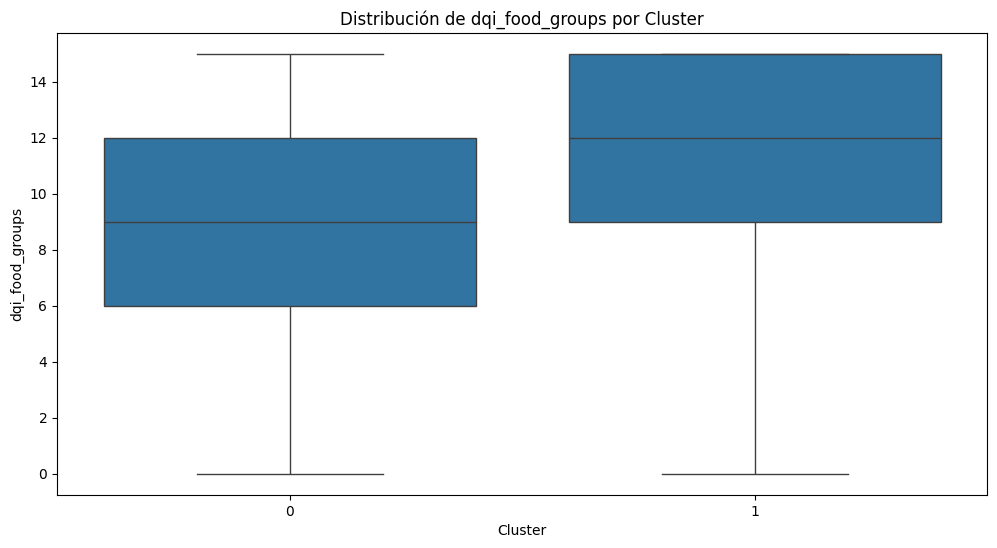

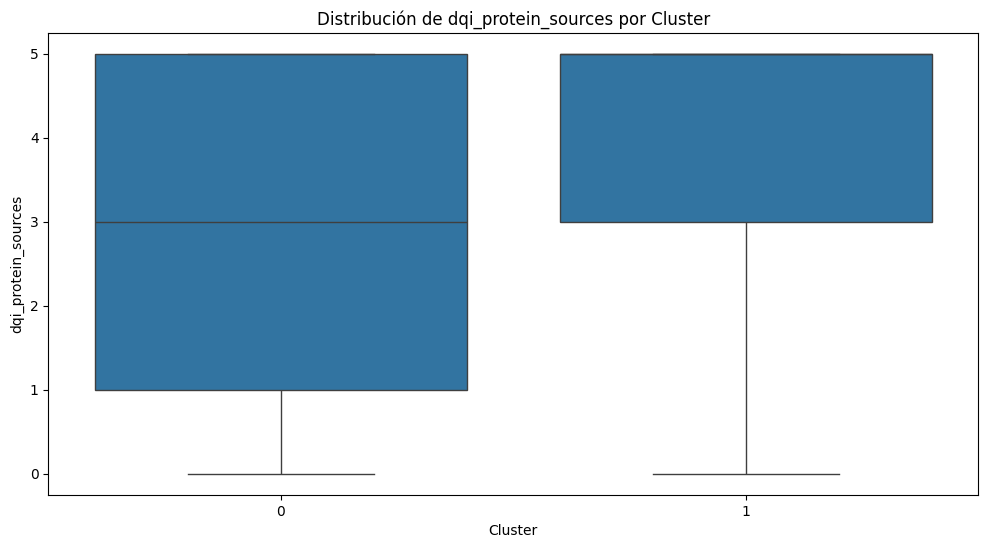

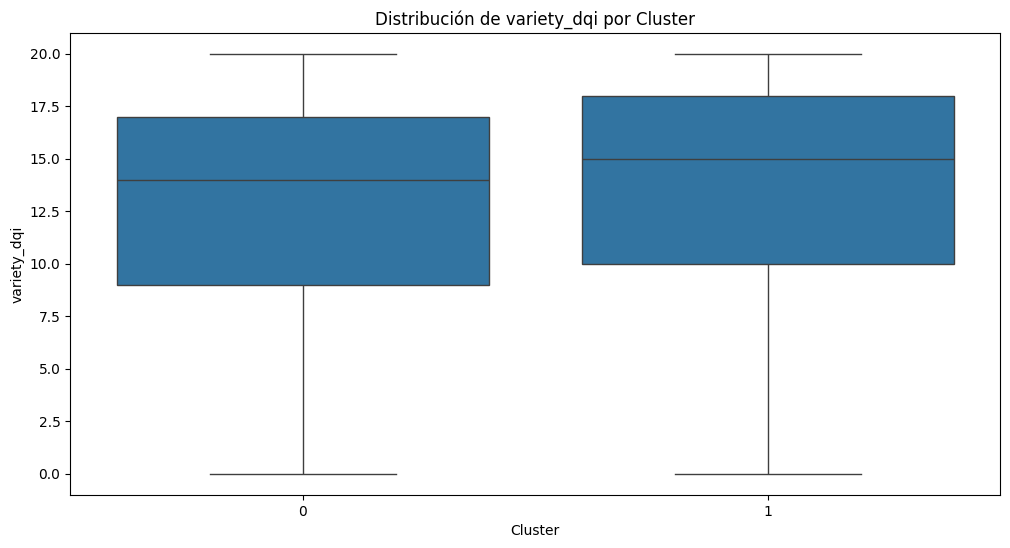

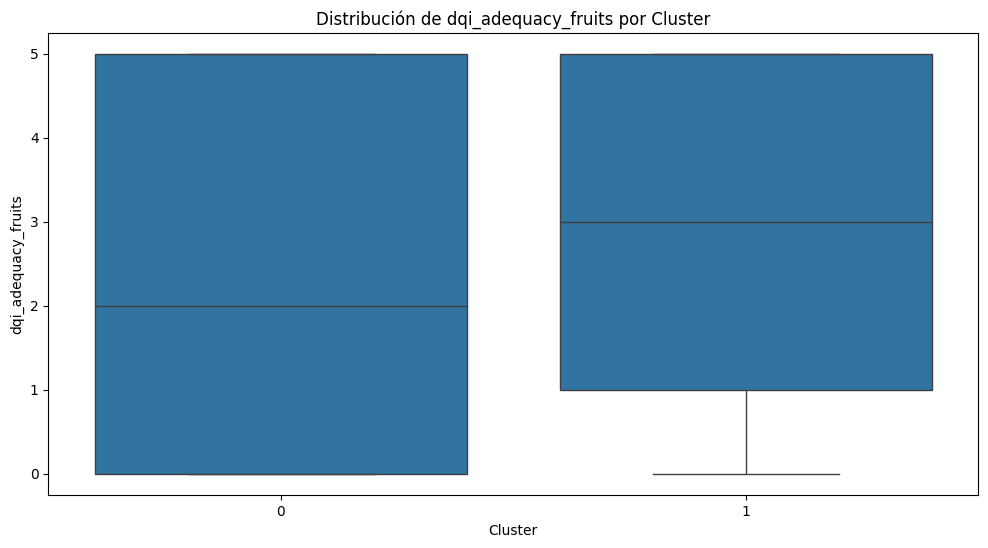

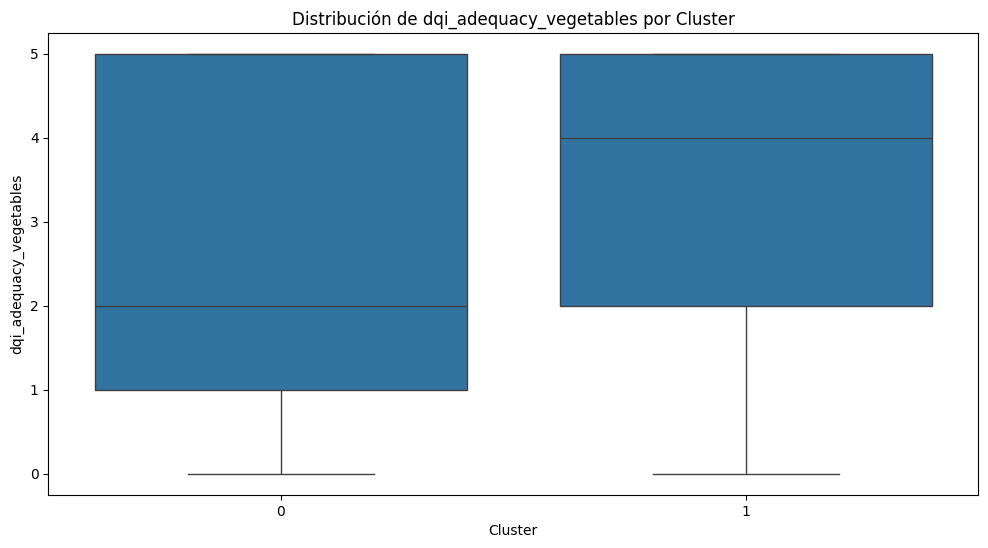

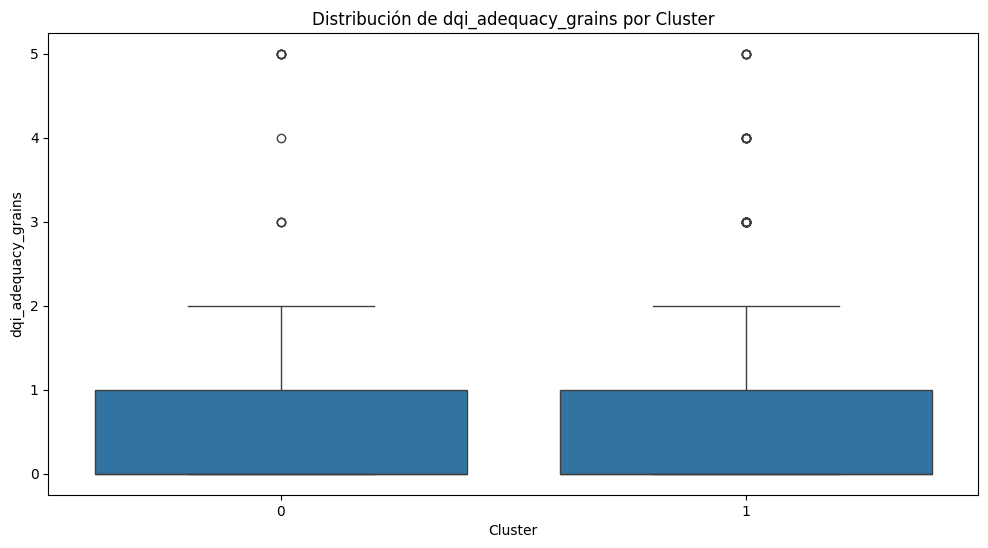

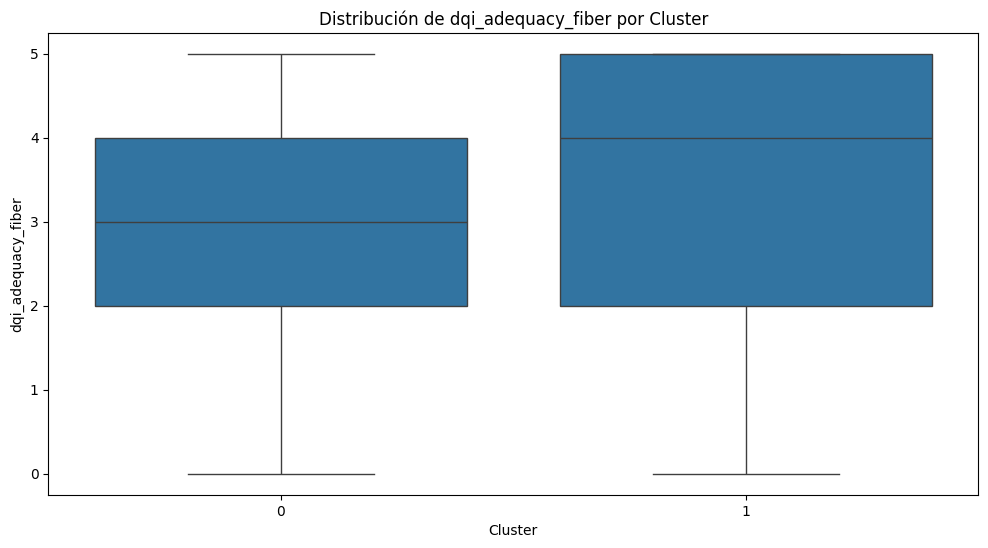

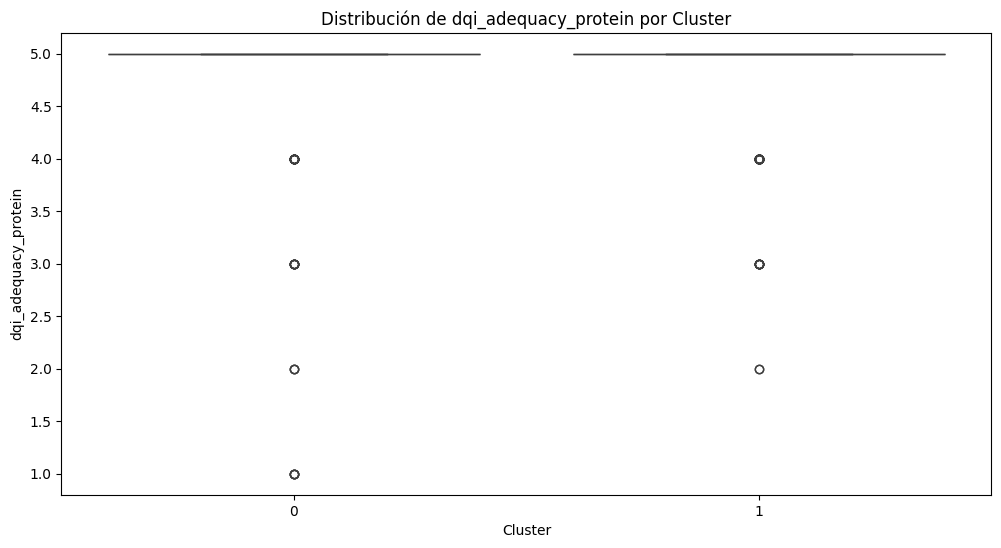

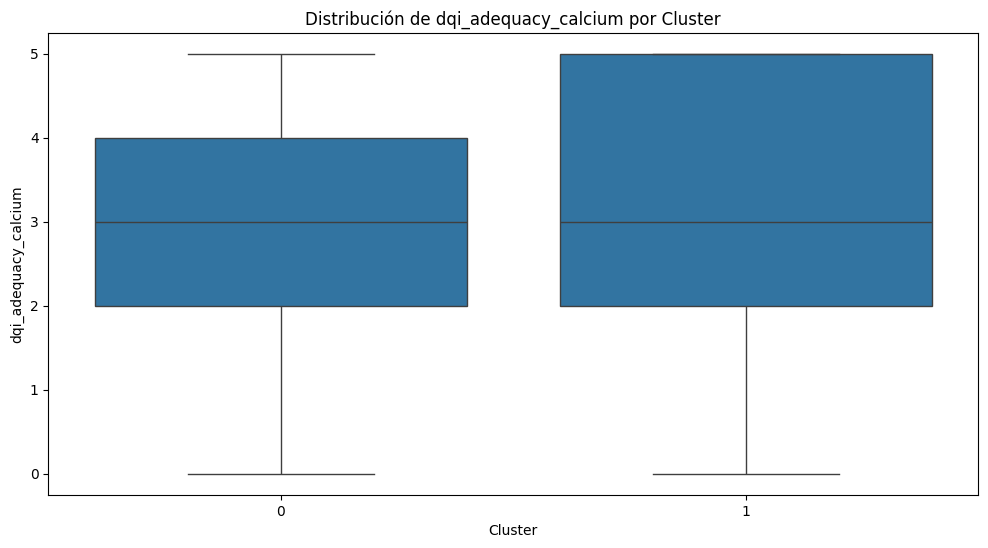

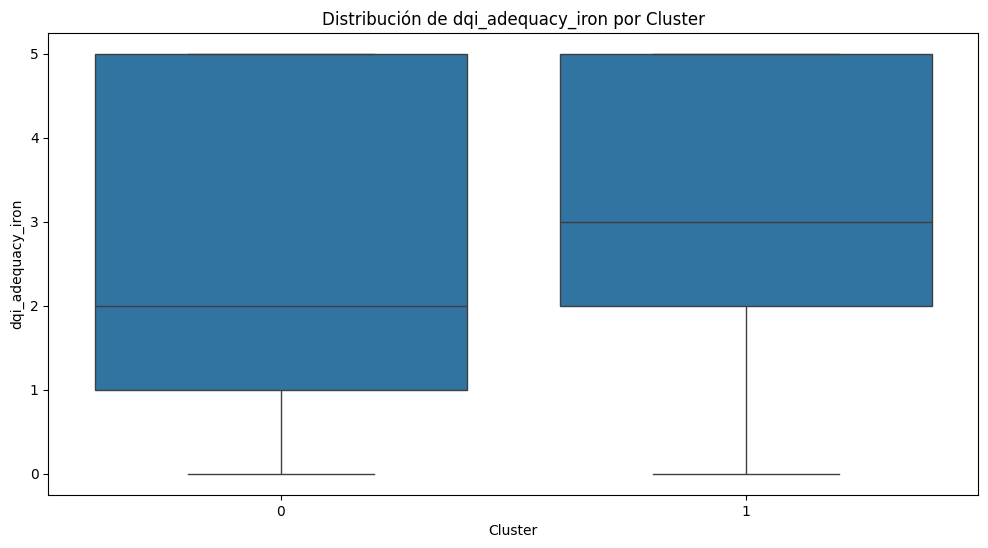

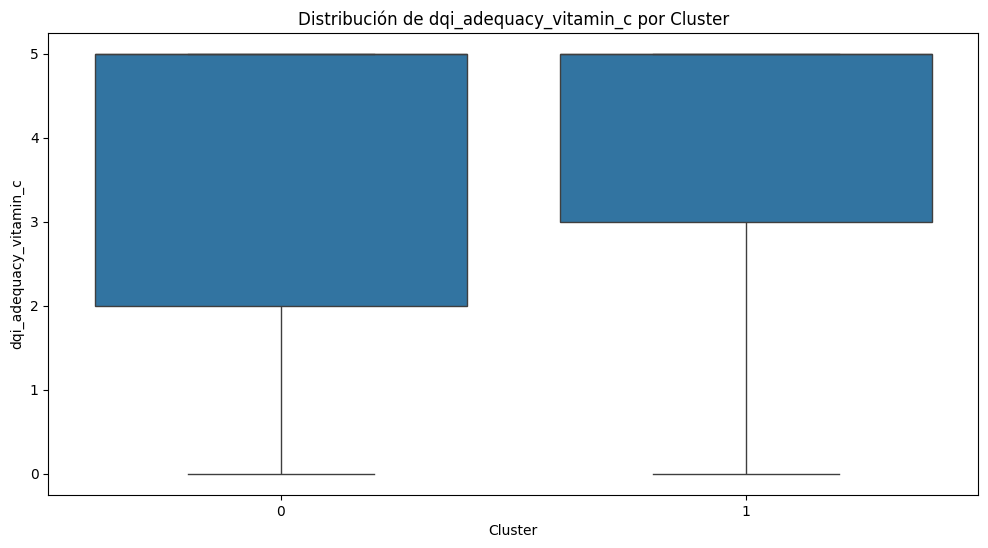

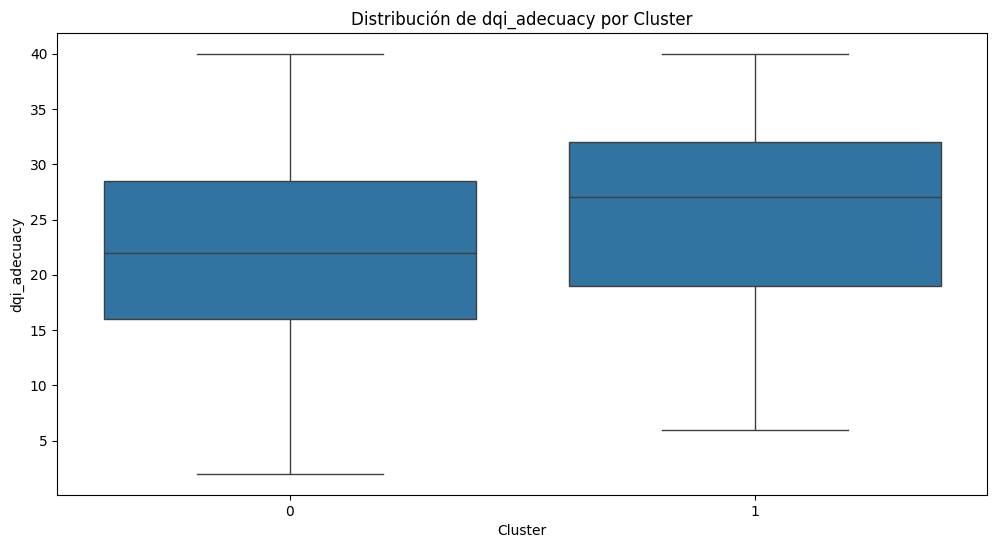

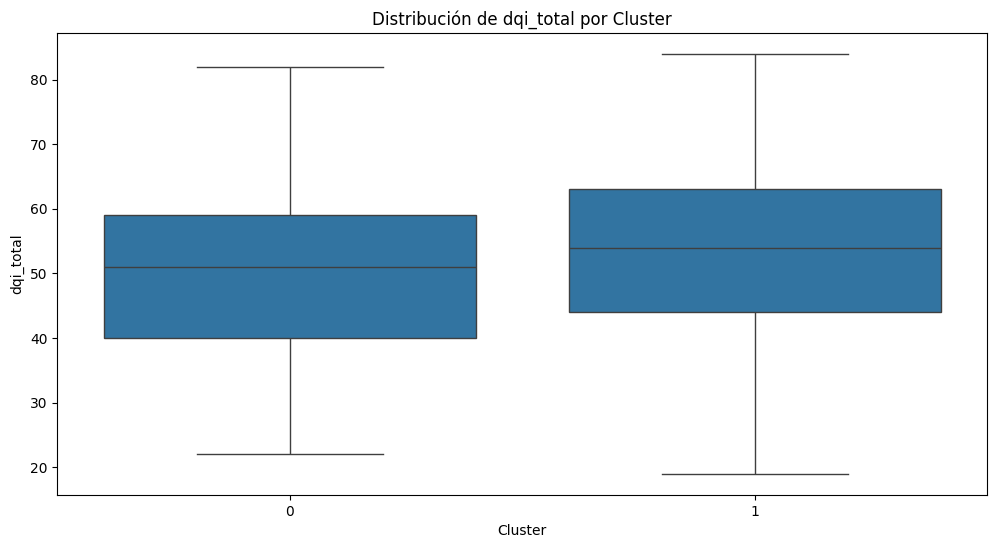

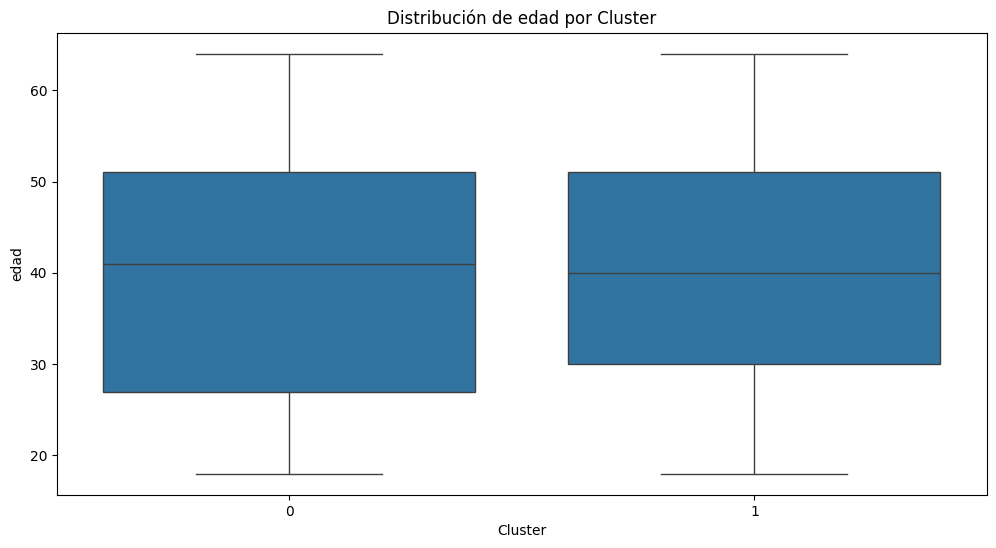

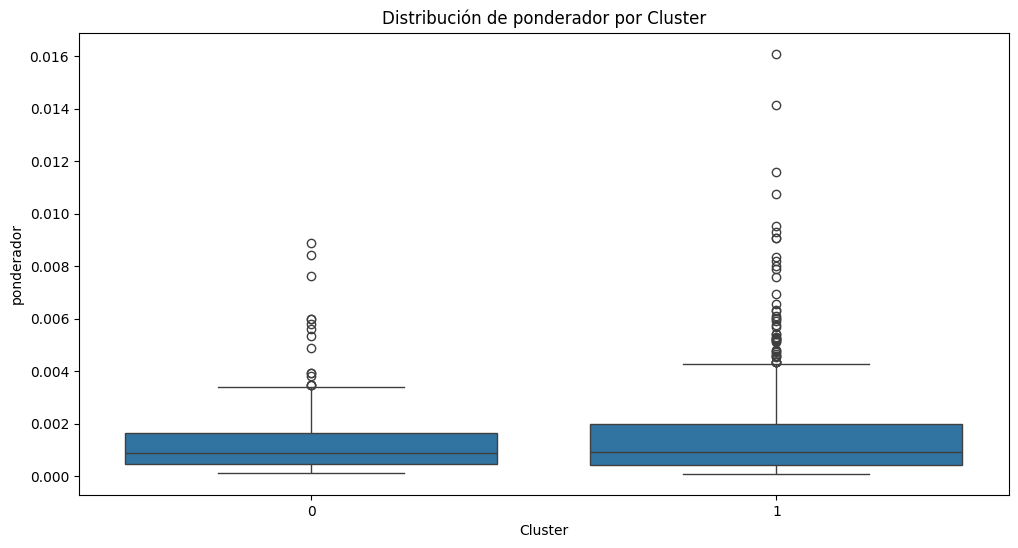

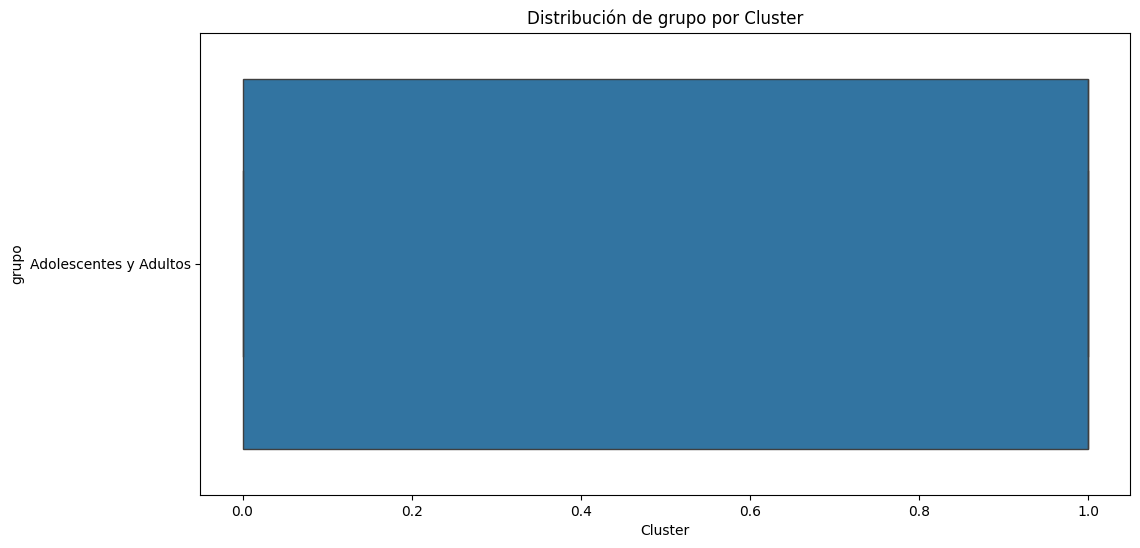

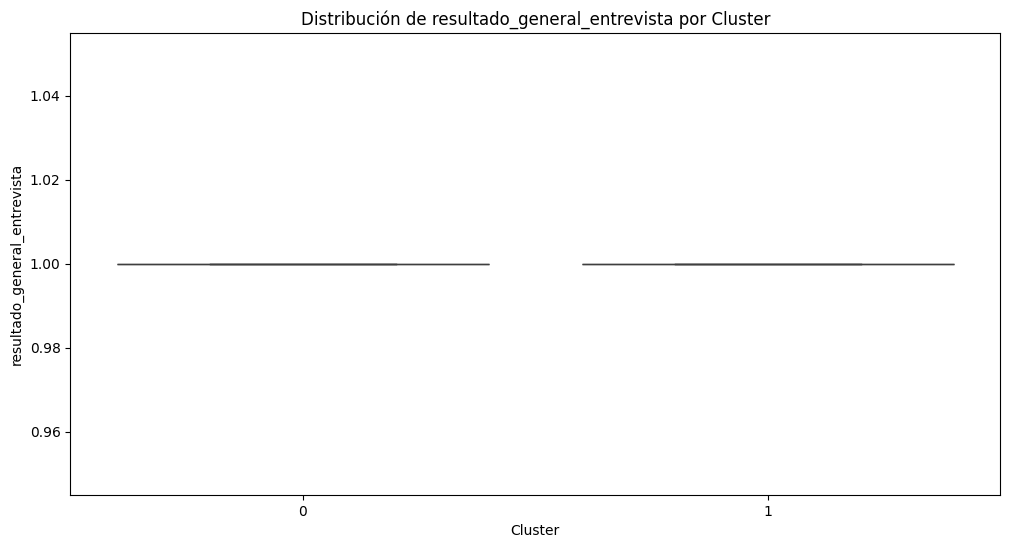

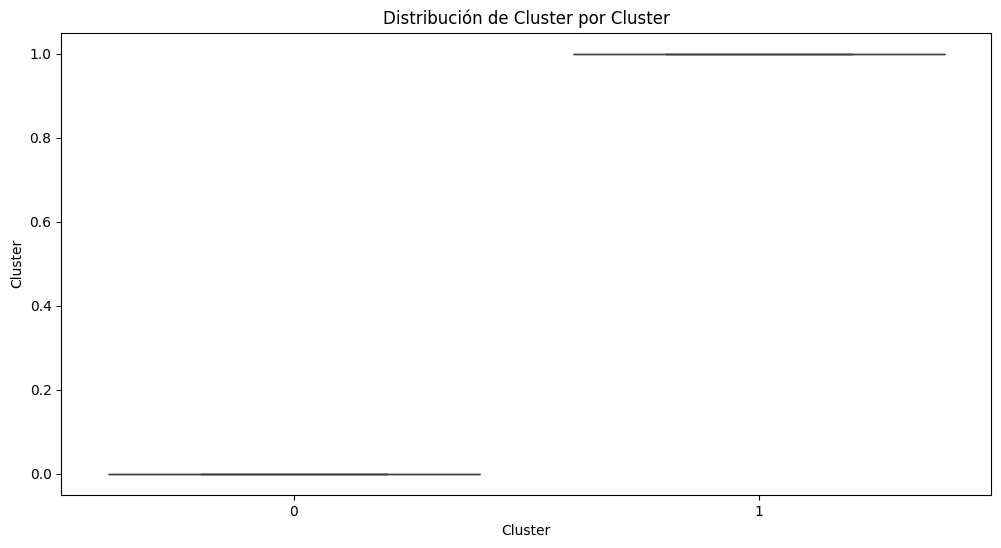

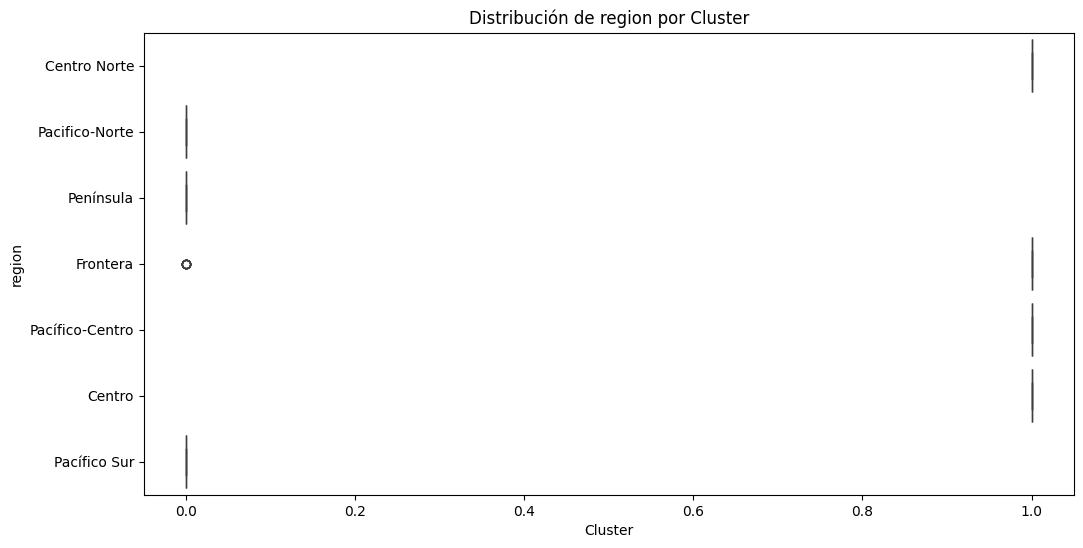

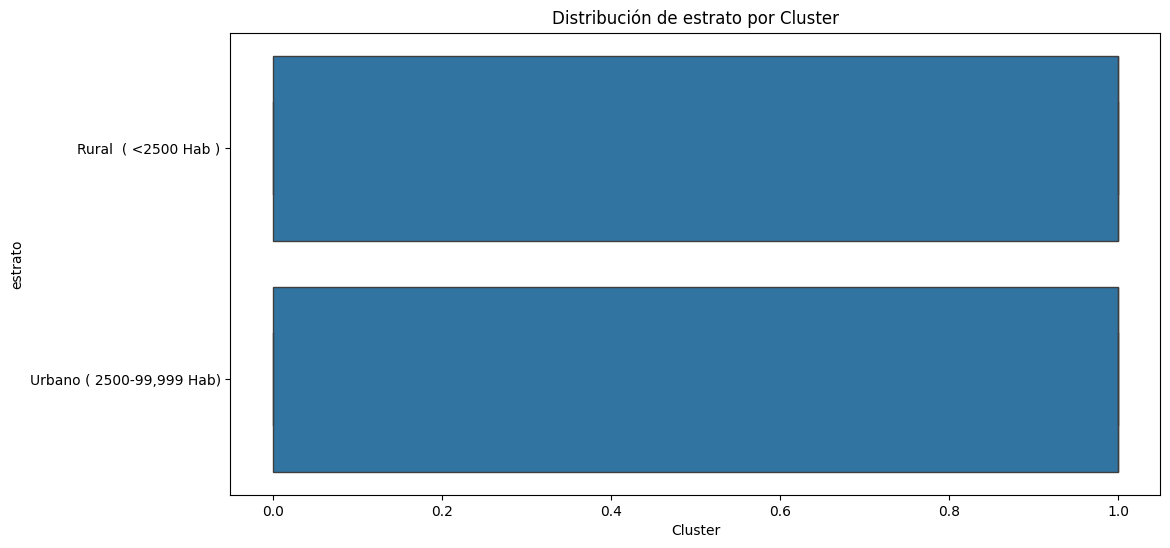

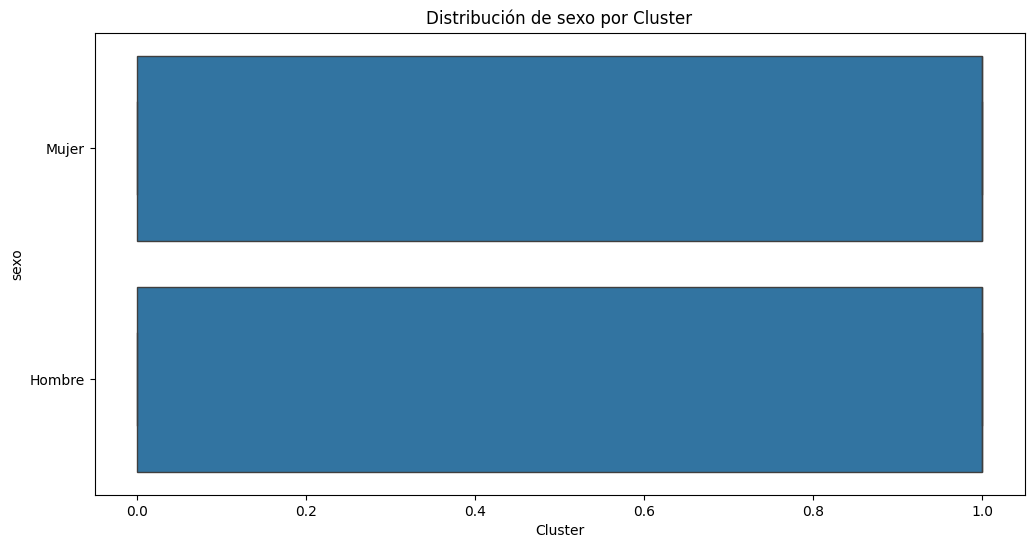

In [446]:
df_dqi = df_dqi.drop('folio_integrante', axis=1)
dqi_columns = df_dqi.columns
for column in dqi_columns:
    boxplot(df_dqi, 'Cluster', column, title=f'Distribución de {column} por Cluster')
    

### Conclusiones del modelo GMM

El data frame usado tiene muchas caracteristicas por lo que se uso PCA para disminuirlas. Como se observa en las graficas del puntaje de la silueta el modelo GMM no da resultados positivos. Es decir, la super posicion entre clusters es muy grande. Incluso en el spider plot se observa como con dos clusters (lo cual ofrece el mejor puntaje de 0.065) se puede observar como es una super posicion muy grande. Al mismo tiempo se puede observar como hay una clara diferenciacion en dos caracteristicas

Debido a los resultados que arroja el GMM no se recomendia como modelo a usarse para este problema.